# Round Aperture Lens Example
Generate a few Gaussian packets from a round aperture, propagate them through a thin lens, and visualise the resulting intensity and phase.

In [1]:
import os
os.environ.setdefault('JAX_ENABLE_X64', '1')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.8')

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.gaussian import make_gaussian_plane_wave_round_aperture
from temgym_core.gaussian_taylor import Lens, run_to_end
from temgym_core.utils import energy2wavelength, zero_phase, FresnelPropagator


In [2]:
jax.config.update('jax_enable_x64', True)

W = 2e-6  # aperture diameter (m)
Nx = Ny = 512
dx = W / Nx
dy = W / Ny
input_grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
input_extent = input_grid.extent

voltage = 100e3  # accelerating voltage (eV)
wavelength = energy2wavelength(voltage)
k0 = 2 * jnp.pi / wavelength

num_rays = 10
rays_in = make_gaussian_plane_wave_round_aperture(
    voltage=voltage,
    aperture_radius=W / 6,
    overlap_factor=1,
    num_rays=num_rays,
    normalization='none',
    sampling='uniform',
)
rays_in = rays_in.to_vector()


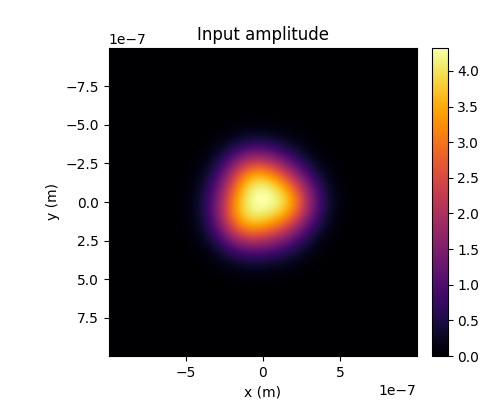

In [3]:
input_field = evaluate_gaussians_for(rays_in, input_grid)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(jnp.abs(input_field), extent=input_extent, cmap='inferno')
ax.set_title('Input amplitude')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

In [4]:
magnification = -1
focal_length = 0.5e-2
z1 = focal_length * (1 / magnification - 1)
z2 = focal_length * (1 - magnification)
print(z1, z2)
lens = Lens(focal_length=focal_length, z=abs(z1))
output_grid = Detector(
    z=abs(z1) + abs(z2),
    pixel_size=(dx, dy),
    shape=(Nx, Ny),
)
output_extent = output_grid.extent

idx_x = Nx // 2
idx_y = Ny // 2
x_coords, y_coords = output_grid.coords_1d

def center_zero_phase(field):
    """Anchor the global phase for easier visual comparison."""
    return zero_phase(field, idx_x, idx_y)

rays_out = jax.vmap(run_to_end, in_axes=(0, None))(rays_in, [input_grid, lens, output_grid])

-0.01 0.01


In [5]:
E_out = evaluate_gaussians_for(rays_out, output_grid)


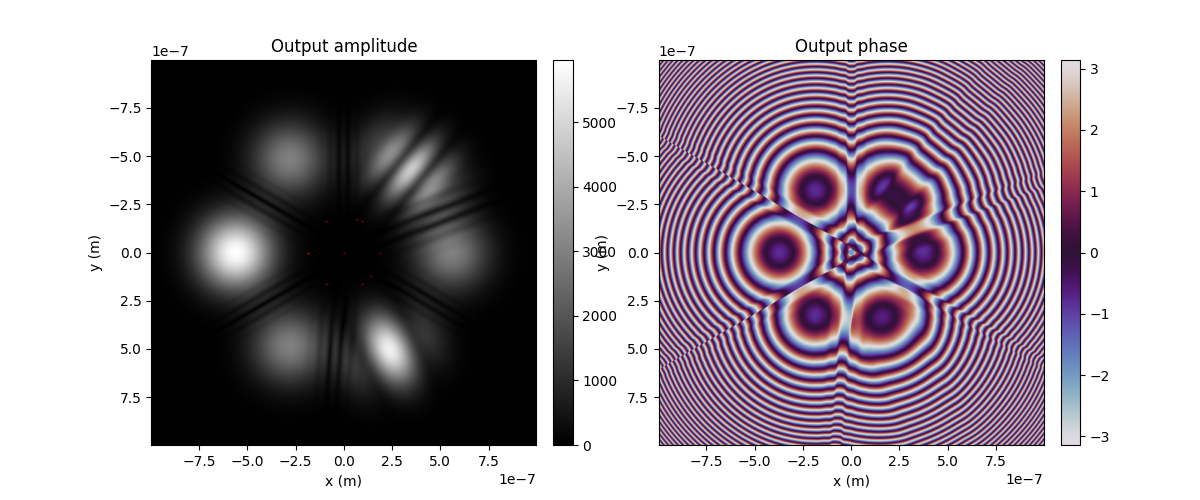

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
amp = axes[0].imshow(np.abs(E_out), extent=output_extent, cmap='gray')
axes[0].set_title('Output amplitude')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].plot(rays_out.x, rays_out.y, 'r.', markersize=0.5, alpha=1)
plt.colorbar(amp, ax=axes[0], fraction=0.046, pad=0.04)

phase = axes[1].imshow(np.angle(E_out), extent=output_extent, cmap='twilight', vmin=-jnp.pi, vmax=jnp.pi)
axes[1].set_title('Output phase')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('y (m)')
plt.colorbar(phase, ax=axes[1], fraction=0.046, pad=0.04)
plt.show()


In [7]:
fresnel_field_at_input = input_field

phase_plate = Lens(focal_length=focal_length, z=focal_length)
phase_mask = jax.vmap(phase_plate.opl_shift)(output_grid.coords).reshape(output_grid.shape)

fresnel_field_before_lens = center_zero_phase(
    FresnelPropagator(fresnel_field_at_input, W, wavelength, abs(z1))
)
fresnel_field_after_lens = center_zero_phase(
    fresnel_field_before_lens * jnp.exp(1j * k0 * phase_mask)
)
fresnel_field_at_back_focal_plane = center_zero_phase(
    FresnelPropagator(fresnel_field_after_lens, W, wavelength, abs(z2))
)

Text(0, 0.5, 'y (m)')

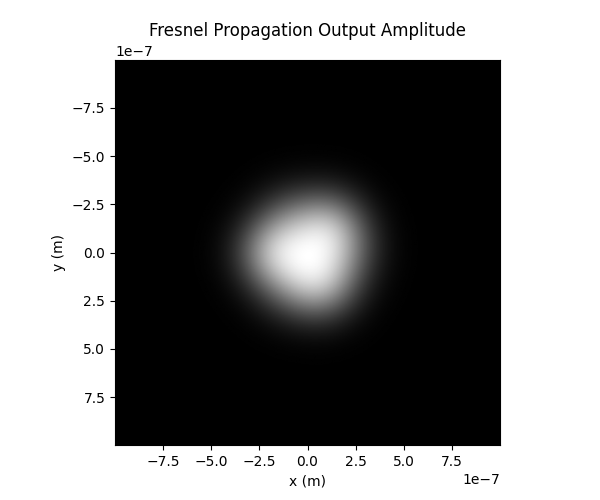

In [8]:
plt.figure(figsize=(6, 5))
plt.imshow(jnp.abs(fresnel_field_at_back_focal_plane), extent=output_extent, cmap='gray')
plt.title('Fresnel Propagation Output Amplitude')
plt.xlabel('x (m)')
plt.ylabel('y (m)')